In [596]:
#1.Load the dataset
from google.colab import files
uploaded=files.upload()

Saving Groceries_dataset.csv to Groceries_dataset (10).csv


In [637]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv('Groceries_dataset.csv')
df.head() # Display the First Five Rows

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,5/1/2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12/12/2015,other vegetables
4,3037,1/2/2015,whole milk


In [638]:
# Display the Last Five Rows
df.tail()

,Member_number,Date,itemDescription
38760,4471,8/10/2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,3/12/2014,fruit/vegetable juice
38764,1521,26-12-2014,cat food


In [639]:
# Check the Shape of the Dataset
df.shape

(38765, 3)

In [640]:
# Display Column Names
df.columns

Index(['Member_number', 'Date', 'itemDescription'], dtype='object')

In [641]:
# Check Dataset Information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [642]:
# Check Data Types
df.dtypes

,0
Member_number,int64
Date,object
itemDescription,object


In [643]:
#Check for Missing Values
print("missing value")
print(df.isnull().sum())

missing value
Member_number      0
Date               0
itemDescription    0
dtype: int64


In [644]:
#Check for Duplicate Records
print(df.duplicated().sum())

759


In [645]:
# Remove Duplicate Records
df=df.drop_duplicates()

In [646]:
# Display Summary Statistics
df.describe()

,Member_number
count,38006.000000
mean,3003.361390
std,1153.659151
min,1000.000000
25%,2001.000000
50%,3005.000000
75%,4007.000000
max,5000.000000


In [647]:
#Count Total Records
print("Total Records:", len(df))

Total Records: 38006


In [648]:
#count number of unique customers.
print("Unique Customers:", df['Member_number'].nunique())

Unique Customers: 3898


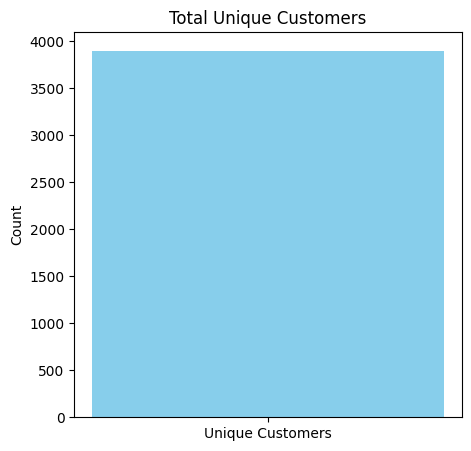

In [649]:
#How many unique customers are there? (Bar Chart)
unique_customers = df['Member_number'].nunique()

plt.figure(figsize=(5,5))
plt.bar(['Unique Customers'], [unique_customers], color='skyblue')
plt.title("Total Unique Customers")
plt.ylabel("Count")
plt.show()

In [650]:
#count number of unique products.
print("Unique Products:", df['itemDescription'].nunique())

Unique Products: 167


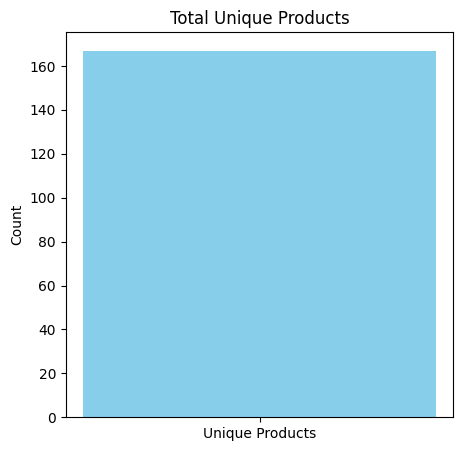

In [652]:
#How many unique products are there? (Bar Chart)
unique_Products = df['itemDescription'].nunique()

plt.figure(figsize=(5,5))
plt.bar(['Unique Products'], [unique_Products], color='skyblue')
plt.title("Total Unique Products")
plt.ylabel("Count")
plt.show()

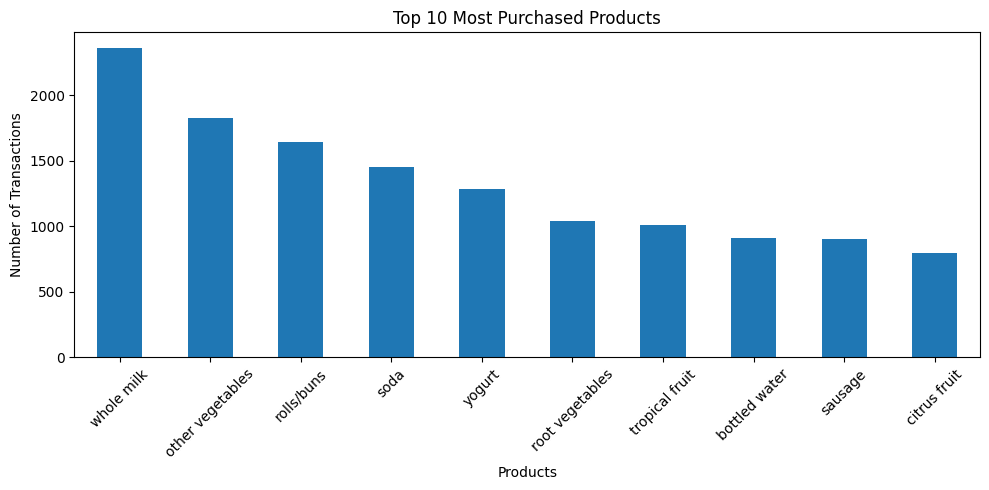

In [655]:
# visualize the Top 10 products
top_products = df['itemDescription'].value_counts().head(10)

# Create bar chart
plt.figure(figsize=(10, 5))
top_products.plot(kind='bar')

plt.title('Top 10 Most Purchased Products')
plt.xlabel('Products')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

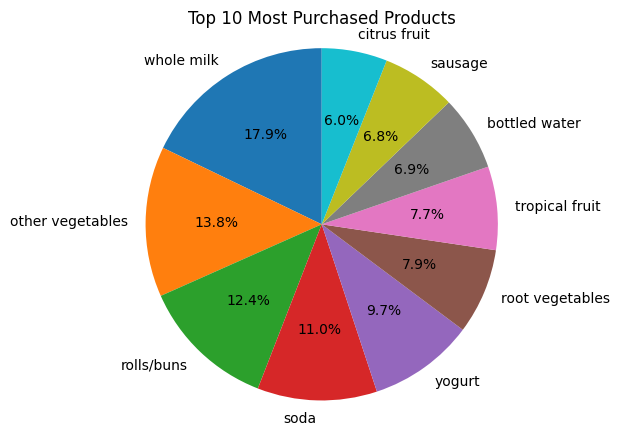

In [656]:
# Count the top 10 most purchased products using pie chart
top10_products = df['itemDescription'].value_counts().head(10)

# Plot pie chart
plt.figure(figsize=(5,5))
plt.pie(
    top10_products,
    labels=top10_products.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Top 10 Most Purchased Products')
plt.axis('equal')  # Makes the pie chart circular

plt.show()

In [657]:
# Determine how many different grocery items are present.
print("Unique Items:", df['itemDescription'].nunique())

Unique Items: 167


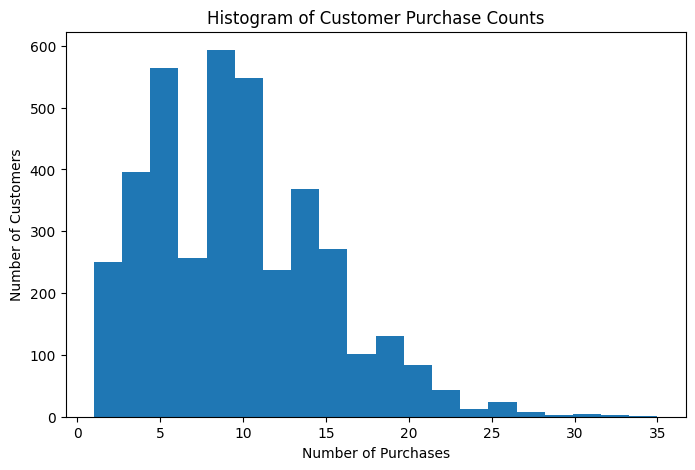

In [658]:
# How many purchases has each customer made? (Histogram)
customer_purchase = df.groupby('Member_number').size()

plt.figure(figsize=(8,5))

plt.hist(customer_purchase, bins=20)

plt.title("Histogram of Customer Purchase Counts")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.show()

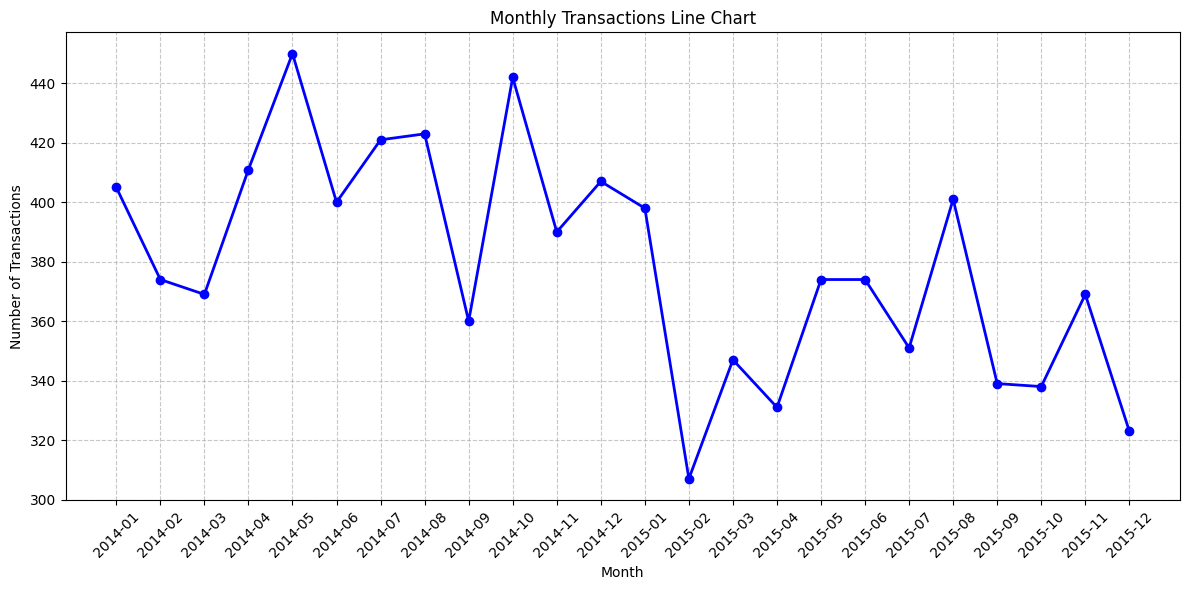

In [659]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Remove rows with invalid dates
df = df.dropna(subset=['Date'])

# Count unique transactions per month
monthly_transactions = (
    df.groupby(df['Date'].dt.to_period('M'))
      .apply(lambda x: x[['Member_number', 'Date']].drop_duplicates().shape[0])
)

# Plot Monthly Transactions Line Chart
plt.figure(figsize=(12,6))

plt.plot(
    monthly_transactions.index.astype(str),
    monthly_transactions.values,
    marker='o',
    linewidth=2,
    color='blue'
)

# Add title and labels
plt.title("Monthly Transactions Line Chart")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

# Rotate x-axis labels
plt.xticks(rotation=45)

# Add grid
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

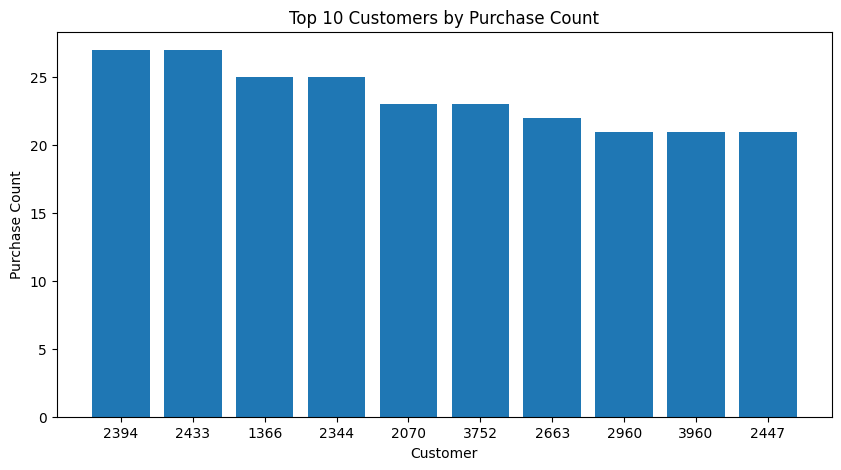

In [660]:
# Which are the Top 10 Customers by Purchase Count? (Bar Chart)
top_customers = (
    df.groupby('Member_number')
      .size()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(
    top_customers.index.astype(str),
    top_customers.values
)

plt.title("Top 10 Customers by Purchase Count")
plt.xlabel("Customer")
plt.ylabel("Purchase Count")

plt.show()

In [661]:
# Count the number of purchases made by each customer
customer_purchase_count = df.groupby('Member_number').size().reset_index(name='Purchase_Count')

# Display the first 10 customers
print(customer_purchase_count.head(10))

   Member_number  Purchase_Count
0           1000              13
1           1001               5
2           1002               6
3           1003               5
4           1004               7
5           1005               2
6           1006               7
7           1008               7
8           1009               6
9           1010               7


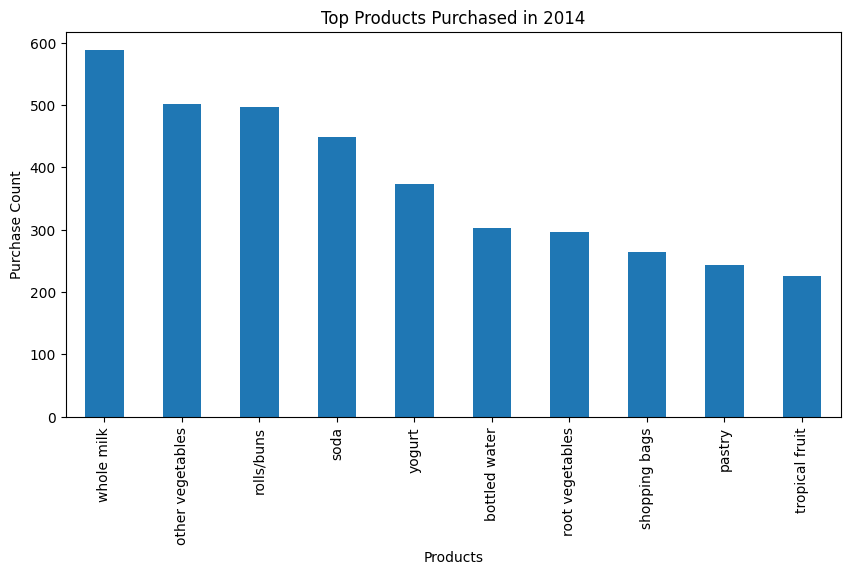

In [662]:
# How many products were purchased in 2014? (Bar Chart)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df_2014 = df[df['Date'].dt.year == 2014]

product_counts = df_2014['itemDescription'].value_counts().head(10)

plt.figure(figsize=(10,5))

product_counts.plot(kind='bar')

plt.title("Top Products Purchased in 2014")
plt.xlabel("Products")
plt.ylabel("Purchase Count")

plt.show()

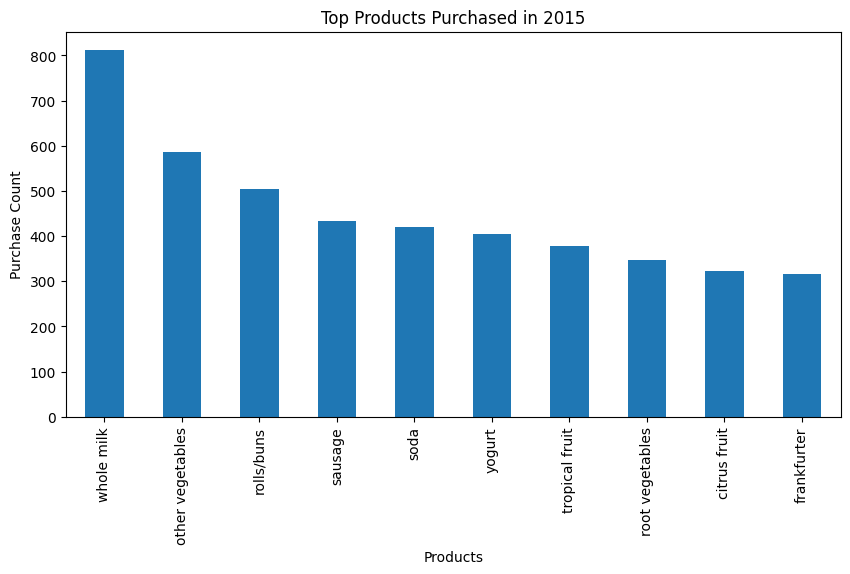

In [663]:
#How many products were purchased in 2015? (Bar Chart)
df_2015 = df[df['Date'].dt.year == 2015]

product_counts = df_2015['itemDescription'].value_counts().head(10)

plt.figure(figsize=(10,5))

product_counts.plot(kind='bar')

plt.title("Top Products Purchased in 2015")
plt.xlabel("Products")
plt.ylabel("Purchase Count")

plt.show()

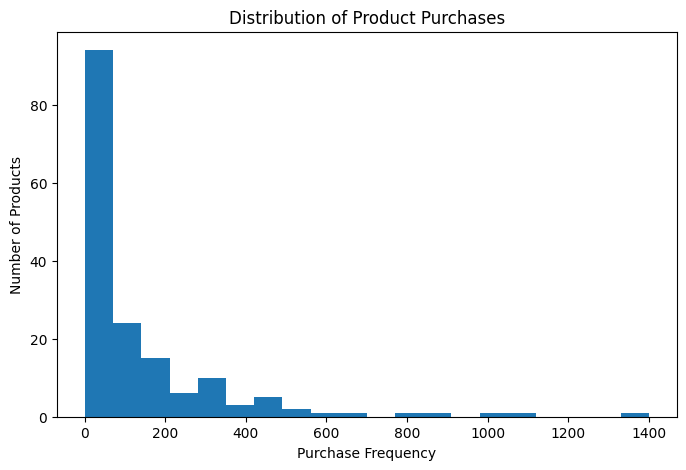

In [664]:
# What is the Distribution of Purchases per Product? (Histogram)
product_frequency = df['itemDescription'].value_counts()

plt.figure(figsize=(8,5))

plt.hist(product_frequency, bins=20)

plt.title("Distribution of Product Purchases")
plt.xlabel("Purchase Frequency")
plt.ylabel("Number of Products")

plt.show()

In [665]:
#convert data frame into transaction data
transaction_data=df.groupby(['Member_number','Date'])['itemDescription'].apply(lambda x: ",".join(x.astype(str))).reset_index()
transaction_data.head()

,Member_number,Date,itemDescription
0,1000,2014-06-24,"whole milk,pastry,salty snack"
1,1000,2015-03-15,"sausage,whole milk,semi-finished bread,yogurt"
2,1000,2015-05-27,"soda,pickled vegetables"
3,1000,2015-07-24,"canned beer,misc. beverages"
4,1000,2015-11-25,"sausage,hygiene articles"


In [666]:
#drop unnecessary columns and save resulting transcation data to a csv file
columns_to_drop=['Member_number','Date']
transaction_data.drop(columns=columns_to_drop,inplace=True,errors='ignore')
#Display few columns of the data
print("\nTransaction data for association rule mining:")
print(transaction_data.head())
transaction_data.shape


Transaction data for association rule mining:
                                 itemDescription
0                  whole milk,pastry,salty snack
1  sausage,whole milk,semi-finished bread,yogurt
2                        soda,pickled vegetables
3                    canned beer,misc. beverages
4                       sausage,hygiene articles


(9104, 1)

In [667]:
#check if 'itemDescription'column exists before processing

if 'itemDescription' in transaction_data.columns:

  #split the itemDescription into individual items

  items_df=transaction_data['itemDescription'].str.split(',',expand=True)

  #concatenate the original Data frame with the new items data frame

  transaction_data=pd.concat([transaction_data,items_df],axis=1)

  items_df.head()

  #drop the original itemDescription column

  transaction_data=transaction_data.drop('itemDescription',axis=1)

  print(transaction_data.head())

else:

  print("The 'itemDescription' column has already been processed or does not exist.")

  print(transaction_data.head())#show current state if already processed

             0                   1                    2       3     4     5  \
0   whole milk              pastry          salty snack    None  None  None   
1      sausage          whole milk  semi-finished bread  yogurt  None  None   
2         soda  pickled vegetables                 None    None  None  None   
3  canned beer     misc. beverages                 None    None  None  None   
4      sausage    hygiene articles                 None    None  None  None   

      6     7     8  
0  None  None  None  
1  None  None  None  
2  None  None  None  
3  None  None  None  
4  None  None  None  


In [668]:
import pandas as pd
#convert items to boolean columns
#we use one-hot encoding toconvert categorical itemDescription values into boolean columns
#each unique item becomes a seperate column,and the presence of an item in a transaction is marked as1,while absence is marked as 0
#The resulting dataframe is stored in df_encoded
df_encoded=pd.get_dummies(transaction_data,prefix='',prefix_sep='').groupby(level=0,axis=1).max()

#save the transaction data to a csv file
#after one hot encoding,we group the data frameby the transaction level and take the maximum valuefor each group
#this ensure that each item column becomes binary(0 or1) indicating the presence of absence of the item in a transaction
#the resulting encoded transaction data is then saved to a csv file for further analysis or use in association rule in mining
df_encoded.to_csv('transaction_data_encoded.csv',index=False)

In [669]:
#association rule mining
#we use the apriori algorithm to perform association rule mining on the encoded transaction data
#the min_support parameter sets the minimum support threshold for an item set to beconsidered frequent
#use_columns=True ensures that column nameare used in the output for better interpretability
from mlxtend.frequent_patterns import apriori,association_rules
frequent_itemsets=apriori(df_encoded,min_support=0.01,use_colnames=True)



In [670]:
#Display the First Five Frequent Itemsets
print(frequent_itemsets.head())

    support        itemsets
0  0.021419      (UHT-milk)
1  0.032733          (beef)
2  0.022847       (berries)
3  0.016476     (beverages)
4  0.044925  (bottled beer)


In [671]:
#Display the Top 10 Frequent Itemsets
frequent_itemsets.head(10)

,support,itemsets
0,0.021419,(UHT-milk)
1,0.032733,(beef)
2,0.022847,(berries)
3,0.016476,(beverages)
4,0.044925,(bottled beer)
5,0.060303,(bottled water)
6,0.037236,(brown bread)
7,0.034710,(butter)
8,0.018893,(butter milk)
9,0.014829,(candy)


In [672]:
print(frequent_itemsets.sort_values(by='support', ascending=False))

     support                        itemsets
59  0.153779                    (whole milk)
40  0.119398              (other vegetables)
44  0.109952                    (rolls/buns)
50  0.095453                          (soda)
60  0.085457                        (yogurt)
..       ...                             ...
12  0.011314                   (chewing gum)
64  0.011314              (whole milk, soda)
61  0.010545  (other vegetables, rolls/buns)
65  0.010545            (yogurt, whole milk)
29  0.010105                         (herbs)

[66 rows x 2 columns]


In [673]:
#generate association rules based on frequent item sets
#we use the frequent itemsets obtained from apriori to generate association rules
#the metric "confidence" is used to measure the strength of the rules
#min_threshold=0.05 sets the minimum confidence thresholdfor a rule to be displayed
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.05)
#display information of the rules
#print the first few rules for inspection
print("associaton rules:")
print(rules.head())

associaton rules:
          antecedents         consequents  antecedent support  \
0  (other vegetables)        (rolls/buns)            0.119398   
1        (rolls/buns)  (other vegetables)            0.109952   
2  (other vegetables)        (whole milk)            0.119398   
3        (whole milk)  (other vegetables)            0.153779   
4        (rolls/buns)        (whole milk)            0.109952   

   consequent support   support  confidence      lift  representativity  \
0            0.109952  0.010545    0.088316  0.803230               1.0   
1            0.119398  0.010545    0.095904  0.803230               1.0   
2            0.153779  0.015488    0.129715  0.843517               1.0   
3            0.119398  0.015488    0.100714  0.843517               1.0   
4            0.153779  0.014279    0.129870  0.844527               1.0   

   leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
0 -0.002583    0.976269      -0.217643  0.048193  -0.024308    0.0

In [674]:
#Display Important Columns
print(rules[['antecedents',
             'consequents',
             'support',
             'confidence',
             'lift']])

          antecedents         consequents   support  confidence      lift
0  (other vegetables)        (rolls/buns)  0.010545    0.088316  0.803230
1        (rolls/buns)  (other vegetables)  0.010545    0.095904  0.803230
2  (other vegetables)        (whole milk)  0.015488    0.129715  0.843517
3        (whole milk)  (other vegetables)  0.015488    0.100714  0.843517
4        (rolls/buns)        (whole milk)  0.014279    0.129870  0.844527
5        (whole milk)        (rolls/buns)  0.014279    0.092857  0.844527
6        (whole milk)              (soda)  0.011314    0.073571  0.770764
7              (soda)        (whole milk)  0.011314    0.118527  0.770764
8            (yogurt)        (whole milk)  0.010545    0.123393  0.802409
9        (whole milk)            (yogurt)  0.010545    0.068571  0.802409


In [675]:
#Display Top 10 Association Rules
top_rules = rules.sort_values(by='lift', ascending=False).head(10)

print(top_rules)

          antecedents         consequents  antecedent support  \
4        (rolls/buns)        (whole milk)            0.109952   
5        (whole milk)        (rolls/buns)            0.153779   
3        (whole milk)  (other vegetables)            0.153779   
2  (other vegetables)        (whole milk)            0.119398   
1        (rolls/buns)  (other vegetables)            0.109952   
0  (other vegetables)        (rolls/buns)            0.119398   
9        (whole milk)            (yogurt)            0.153779   
8            (yogurt)        (whole milk)            0.085457   
7              (soda)        (whole milk)            0.095453   
6        (whole milk)              (soda)            0.153779   

   consequent support   support  confidence      lift  representativity  \
4            0.153779  0.014279    0.129870  0.844527               1.0   
5            0.109952  0.014279    0.092857  0.844527               1.0   
3            0.119398  0.015488    0.100714  0.843517      

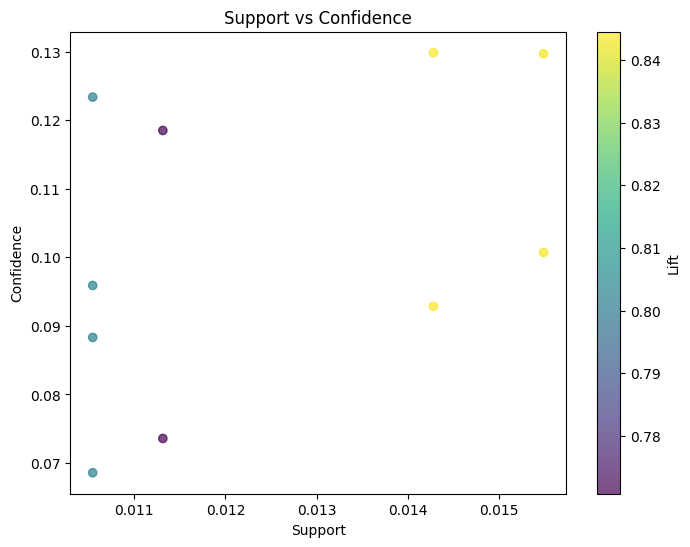

In [676]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(scatter, label='Lift')

plt.title('Support vs Confidence')
plt.xlabel('Support')
plt.ylabel('Confidence')


plt.show()

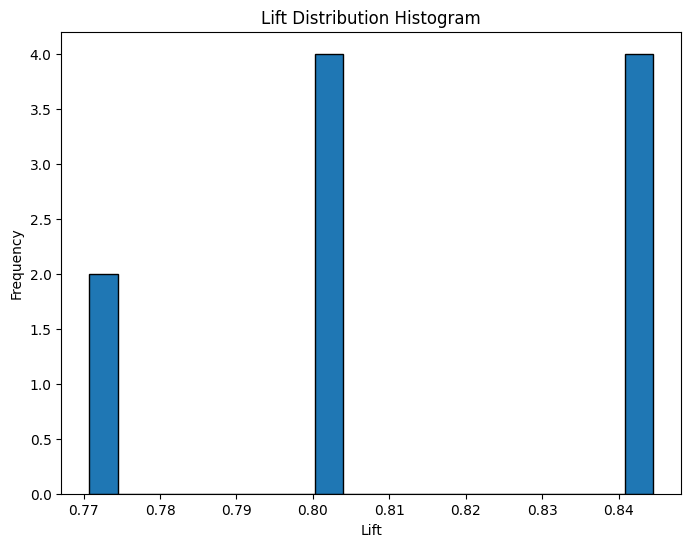

In [677]:
#Create Lift Distribution Histogram
plt.figure(figsize=(8,6))

plt.hist(
    rules['lift'],
    bins=20,
    edgecolor='black'
)

plt.title('Lift Distribution Histogram')
plt.xlabel('Lift')
plt.ylabel('Frequency')


plt.show()

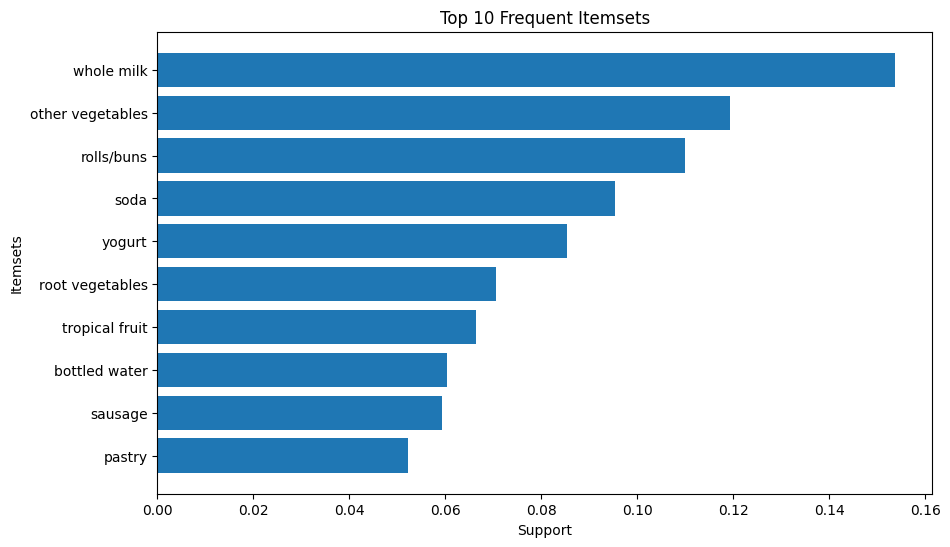

In [678]:
# Get Top 10 frequent itemsets based on support
top10 = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

# Convert itemsets to string format
top10['itemsets'] = top10['itemsets'].apply(lambda x: ', '.join(list(x)))

# Plot bar chart
plt.figure(figsize=(10,6))

plt.barh(top10['itemsets'], top10['support'])

plt.title('Top 10 Frequent Itemsets')
plt.xlabel('Support')
plt.ylabel('Itemsets')

plt.gca().invert_yaxis()  # Highest support on top

plt.show()

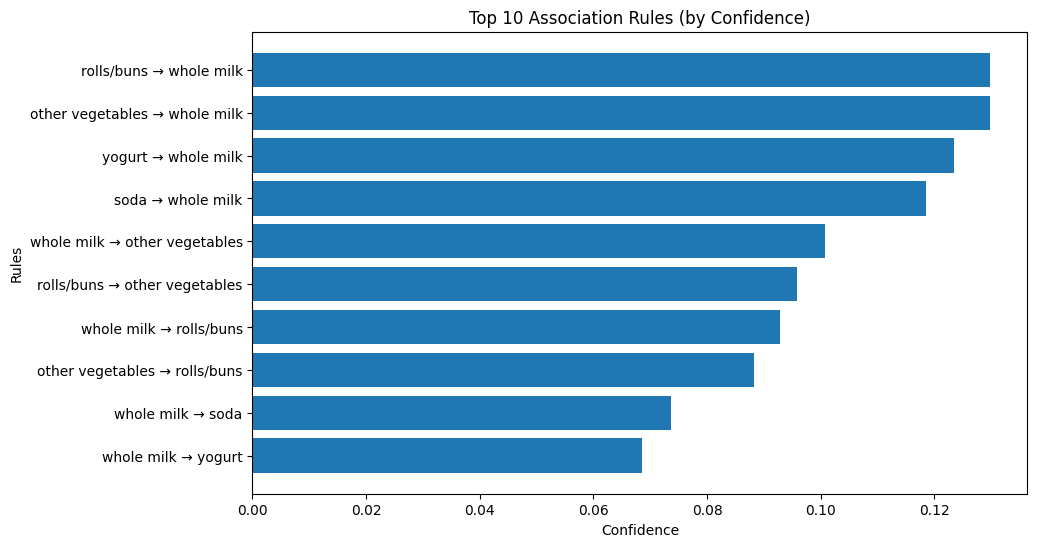

In [679]:
# Get Top 10 association rules based on confidence
top10_rules = rules.sort_values(by='confidence', ascending=False).head(10)

# Convert antecedents → consequents into readable format
top10_rules['rule'] = top10_rules['antecedents'].apply(lambda x: ', '.join(list(x))) + \
                      " → " + \
                      top10_rules['consequents'].apply(lambda x: ', '.join(list(x)))

# Plot bar chart
plt.figure(figsize=(10,6))

plt.barh(top10_rules['rule'], top10_rules['confidence'])

plt.title('Top 10 Association Rules (by Confidence)')
plt.xlabel('Confidence')
plt.ylabel('Rules')

plt.gca().invert_yaxis()  # Highest confidence on top

plt.show()